In [1]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
import os
import glob
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

Welcome to JupyROOT 6.26/16


In [2]:
#Our standard function library for time slicing and 3D clustering. 

def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

#returns an array which contains total merged hits, PEs, for each neutrino event, used for creating metrics.
def ReturnNeutrinoInfoArray(time_sorted_hits, number_of_neutrinos):
    
    neutrino_PE_array_merged = np.zeros((number_of_neutrinos, 3))
    for i in range(number_of_neutrinos):
        PEs = 0.
        sub_array = time_sorted_hits[time_sorted_hits[:, 0] == i]
        n_hits = 0
        for hit in sub_array:
            n_hits += 1
            PEs += hit[6]
        neutrino_PE_array_merged[i][0] = i
        neutrino_PE_array_merged[i][1] = PEs
        neutrino_PE_array_merged[i][2] = n_hits

    return(neutrino_PE_array_merged)

In [3]:
#Kernel Density Functions
def MakeKDSegments(slice_list, selected_slice, bandwidth = 15, plot = False):
    hit_ts = slice_list[selected_slice][:,5]

    # 1D input data
    data = hit_ts
    data_reshaped = hit_ts.reshape(-1, 1)

    # KDE fitting using a gaussian kernel. 
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data_reshaped)

    # Evaluate KDE on a fine grid - project our function onto a fine grid to look for local minima
    #This is a necessary step to be able to find our local minima numerically. Basically the kde gives us our functional form, we need to plot it on points to get out the pdf. 
    #The plotting with the points is accomplished by pulling the score_samples method, which returns log likelihoods. We then convert these into actually probabilitiy densities. 
    x_plot = np.linspace(data.min() - 2, data.max() + 2, 5000).reshape(-1, 1)
    log_dens = kde.score_samples(x_plot)
    dens = np.exp(log_dens)

    # Find valleys in KDE curve (ie, local minima)
    #Can use scipy peak finding, but invert data so we are really finding the local minima! Returns indices
    inverted = -dens
    valleys, _ = find_peaks(inverted)
    valley_positions = x_plot[valleys].flatten() #this step maps our indices onto actual times. 

    # Auto-labeling: assign cluster index based on which region the point falls into
    def assign_cluster(x, boundaries):
        for i, b in enumerate(boundaries): #will loop through boundaries and the last one assigned will be the one it fits into.
            if x < b:
                return i
        return len(boundaries) 

    labels = np.array([assign_cluster(x, valley_positions) for x in data]) #assign labels to our data

    
    if (plot == True): #output a KDE plot
        plt.plot(x_plot[:, 0], dens, label="KDE")
        plt.scatter(data, np.zeros_like(data), c=labels, cmap='tab20', s=50, label="Time Segments")
        for v in valley_positions:
            plt.axvline(v, color='gray', linestyle='--', linewidth=1)
        plt.title("KDE-based hit Clustering with Auto-Labels")
        plt.xlabel("Hit Time")
        plt.yticks([])
        plt.legend()
        plt.show()

    clusters_added = np.column_stack((slice_list[selected_slice], labels)) #save our data with cluster labels added to the end of each hit row. 
    
    return(clusters_added)

def FullFileKDCluster(slice_list_, bandwidth_ = 15): #this will run clustering on the whole file!
    n_slices = len(slice_list_) #This is the number of time slices
    slice_container = []
    for i in range(n_slices):
        clustered_slice = MakeKDSegments(slice_list_, i, bandwidth = bandwidth_, plot = False)
        slice_container.append(clustered_slice)
        
    #now just return the list with the added cluster information!
    return(slice_container)

def FullFileClusterEvaluate(list_of_spills_, neutrino_truth_array, number_of_neutrinos): #takes an argument like a list of spills with their fine clustering applied
    #We can define a containment array, will be looping over both spills and clusters and checking for the best cluster!
    containment_array = np.zeros((number_of_neutrinos,7)) #|nn | hit containment | PE containment | best hit containment spill | best hit containment cluster | best PE containment spill | best PE containment cluster |
    #Initialize with nns
    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    cluster_occupancy = []

    #Big nested loop coming up
    #Loop over each slice
    for i, spill_ in enumerate(list_of_spills_) :
        #Now we need to identify the clusters:
        cluster_numbers = np.unique(spill_[:,-1]) #grab the cluster numbers from within the spill
        for cluster_number in cluster_numbers:
            cluster_sub_array = spill_[ spill_[:,-1] == cluster_number ] #this is an array of all the hits in a given cluster. 
            #now do a grouping by neutrino number
            nns_in_cluster = np.unique(cluster_sub_array[:,0])
            cluster_occupancy.append(len(nns_in_cluster))
            #now loop over the neutrino numbers
            for nn in nns_in_cluster:
                nn_sub_array = cluster_sub_array[ cluster_sub_array[:,0] == nn ]  #array of hits in a cluster with a given neutrino number
                #Grab truth information for this neutrino number
                total_PEs = neutrino_truth_array[int(nn)][1] #total PE
                total_hits = neutrino_truth_array[int(nn)][2] #total hits
                cluster_PE = np.sum(nn_sub_array[:,6])
                cluster_hits = np.shape(nn_sub_array)[0]

                if (containment_array[int(nn)][1]) <= (cluster_hits / total_hits) :
                    containment_array[int(nn)][1] = cluster_hits / total_hits #hits contained
                    containment_array[int(nn)][3] = i #slice
                    containment_array[int(nn)][4] = cluster_number #cluster number within slice

                if (containment_array[int(nn)][2]) <= (cluster_PE / total_PEs) :
                    containment_array[int(nn)][2] = cluster_PE / total_PEs #PEs contained
                    containment_array[int(nn)][5] = i #this slice. 
                    containment_array[int(nn)][6] = cluster_number #cluster number within slice

    #apply a masking such that we are only reviewing neutrino events with tms hits
    neutrinos_with_TMS_hits = np.where(neutrino_truth_array[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    return(containment_array, masked_containment_array, cluster_occupancy) #now we return both arrays  


def SingleKDSegments(time_segment, bandwidth = 15, plot = False):
    hit_ts = time_segment[:,5]

    # 1D input data
    data = hit_ts
    data_reshaped = hit_ts.reshape(-1, 1)

    # KDE fitting using a gaussian kernel. 
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data_reshaped)

    # Evaluate KDE on a fine grid - project our function onto a fine grid to look for local minima
    #This is a necessary step to be able to find our local minima numerically. Basically the kde gives us our functional form, we need to plot it on points to get out the pdf. 
    #The plotting with the points is accomplished by pulling the score_samples method, which returns log likelihoods. We then convert these into actually probabilitiy densities. 
    x_plot = np.linspace(data.min() - 2, data.max() + 2, 5000).reshape(-1, 1)
    log_dens = kde.score_samples(x_plot)
    dens = np.exp(log_dens)

    # Find valleys in KDE curve (ie, local minima)
    #Can use scipy peak finding, but invert data so we are really finding the local minima! Returns indices
    inverted = -dens
    valleys, _ = find_peaks(inverted)
    valley_positions = x_plot[valleys].flatten() #this step maps our indices onto actual times. 

    # Auto-labeling: assign cluster index based on which region the point falls into
    def assign_cluster(x, boundaries):
        for i, b in enumerate(boundaries): #will loop through boundaries and the last one assigned will be the one it fits into.
            if x < b:
                return i
        return len(boundaries) 

    labels = np.array([assign_cluster(x, valley_positions) for x in data]) #assign labels to our data

    
    if (plot == True): #output a KDE plot
        plt.plot(x_plot[:, 0], dens, label="KDE")
        plt.scatter(data, np.zeros_like(data), c=labels, cmap='tab20', s=50, label="Time Segments")
        for v in valley_positions:
            plt.axvline(v, color='gray', linestyle='--', linewidth=1)
        plt.title("KDE-based hit Clustering with Auto-Labels")
        plt.xlabel("Hit Time")
        plt.yticks([])
        plt.legend()
        plt.show()

    clusters_added = np.column_stack((time_segment, labels)) #save our data with cluster labels added to the end of each hit row. 
    
    return(clusters_added)

In [4]:
def MakeKDSegmentsSpill(slice_list, bandwidth = 15, mesh_points = 1000, plot = False):
    hit_ts = slice_list[:,5]

    #mesh_points = int((max(hit_ts) - min(hit_ts)) // 2) #how many points to evaluate our function at to determine the vally points?
    # 1D input data
    data = hit_ts
    data_reshaped = hit_ts.reshape(-1, 1)

    # KDE fitting
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data_reshaped)

    # Evaluate KDE on a fine grid - project our function onto a fine grid to look for local minima
    #This is a necessary step to be able to find our local minima numerically.
    x_plot = np.linspace(data.min() - 2, data.max() + 2, mesh_points).reshape(-1, 1)
    log_dens = kde.score_samples(x_plot)
    dens = np.exp(log_dens)

    # Find valleys in KDE curve (ie, local minima)
    inverted = -dens
    valleys, _ = find_peaks(inverted)
    valley_positions = x_plot[valleys].flatten()

    # Auto-labeling: assign cluster index based on which region the point falls into
    def assign_cluster(x, boundaries):
        for i, b in enumerate(boundaries):
            if x < b:
                return i
        return len(boundaries)  # last cluster

    labels = np.array([assign_cluster(x, valley_positions) for x in data])

    
    if (plot == True): #output a KDE plot
        plt.plot(x_plot[:, 0], dens, label="KDE")
        #plt.scatter(data, np.zeros_like(data), c=labels, cmap='tab20', s=20, label="Time Segments")
        for v in valley_positions:
            plt.axvline(v, color='gray', linestyle='--', linewidth=1)
        plt.title("KDE-based Spill Clustering with Auto-Labels")
        plt.xlabel("Hit Time (ns)")
        #plt.yticks([])
        #plt.legend()
        plt.show()

    clusters_added = np.column_stack((slice_list, labels))
    print(f"We found {len(np.unique(labels))} clusters")
    
    return(clusters_added)


def SpillWiseClusterEvaluate(spill_clustered_, neutrino_truth_array, number_of_neutrinos):
    #We can define a containment array, will be looping over both slices and clusters and checking for the best cluster!
    containment_array = np.zeros((number_of_neutrinos,7)) #|nn | hit containment | PE containment | best hit containment slice | best hit containment cluster | best PE containment slice | best PE containment cluster |
    #Initialize with nns
    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    cluster_occupancy = []

    #Big nested loop coming up
    #Loop over each slice
    nns_represented = np.unique(spill_clustered_[:,0])
    
    
    cluster_numbers = np.unique(spill_clustered_[:,-1]) #grab the cluster numbers
    for cluster_number in cluster_numbers:
        i = 0
        cluster_sub_array = spill_clustered_[ spill_clustered_[:,-1] == cluster_number ] #this is an array of all the hits in a given cluster. 
        #now do a grouping by neutrino number
        nns_in_cluster = np.unique(cluster_sub_array[:,0])
        cluster_occupancy.append(len(nns_in_cluster))
        #now loop over the neutrino numbers
        for nn in nns_in_cluster:
            nn_sub_array = cluster_sub_array[ cluster_sub_array[:,0] == nn ]  #array of hits in a cluster with a given neutrino number
            #Grab truth information for this neutrino number
            total_PEs = neutrino_truth_array[int(nn)][1] #total PE
            total_hits = neutrino_truth_array[int(nn)][2] #total hits
            cluster_PE = np.sum(nn_sub_array[:,6])
            cluster_hits = np.shape(nn_sub_array)[0]

            if (containment_array[int(nn)][1]) <= (cluster_hits / total_hits) :
                containment_array[int(nn)][1] = cluster_hits / total_hits #hits contained
                containment_array[int(nn)][3] = i #slice
                containment_array[int(nn)][4] = cluster_number #cluster number within slice

            if (containment_array[int(nn)][2]) <= (cluster_PE / total_PEs) :
                containment_array[int(nn)][2] = cluster_PE / total_PEs #PEs contained
                containment_array[int(nn)][5] = i #this slice. 
                containment_array[int(nn)][6] = cluster_number #cluster number within slice

    #apply a masking such that we are only reviewing neutrino events with tms hits
    neutrinos_with_TMS_hits = np.where(neutrino_truth_array[:, 2] != 0)[0] #check that number of hits is non-zero. Not enough! Also need to mask for stuff in spill
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]
    masked_containment_array = masked_containment_array[masked_containment_array[:,0] <= max(nns_represented) ] #this is troll and will need to be patched. 

    return(containment_array, masked_containment_array, cluster_occupancy) #now we return both arrays  

In [5]:
#Load in the files that we need:
#Sadly we need to load in the original edep-sim file to do any analysis that involves information about the origin neutrino (ie, if the track is a muon etc.) This ofc would have been too much to drag along through whole series. 
edep_file = root.TFile("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002509.EDEPSIM_SPILLS.root") #grab the edep-sim file, can pull neutrino vertex information as well as event characteristics
edep_detsim = edep_file.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
edep_events = edep_file.Get("EDepSimEvents") #grab events, mostly for the trajectories (can help characterize the event)
gRooTrackerTree = edep_detsim.gRooTracker #the gRooTracker contains neutrino vertex information
#Pull the merged events
merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2509.npz') #grab merged hits for the file, not time sliced - some destination in /sdf/data/neutrino/summer25/ktwall/tms_timing/multihit
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
#Pull the actual time slices
#time_slice_file = uproot.open(" /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2500_sliced_init-8.0_drop-4.0.root") #grab the time slice output
#time_slices = time_slice_file['Time Slices']
#basic_metrics = time_slice_file['Metrics']

In [6]:
#reload files for spill level stuff, just cuz
edep_file_up = uproot.open('/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002509.EDEPSIM_SPILLS.root')
edep_events = edep_file_up['EDepSimEvents']
edep_detsim_up = edep_file_up['DetSimPassThru']
edep_tracker_up = edep_detsim_up['gRooTracker']
n_neutrino_events = merged_hits_file['second']
print(n_neutrino_events)

5849


In [7]:
interaction_times = edep_tracker_up['EvtVtx'].arrays().EvtVtx[:,3] / (10**9)
spills = (interaction_times // 1.2)
neutrino_numbers = np.arange(int(n_neutrino_events))
full_spill_lookup = np.column_stack((neutrino_numbers,spills)) #full lookup

Text(0.5, 0, 'neutrino interaction time (s)')

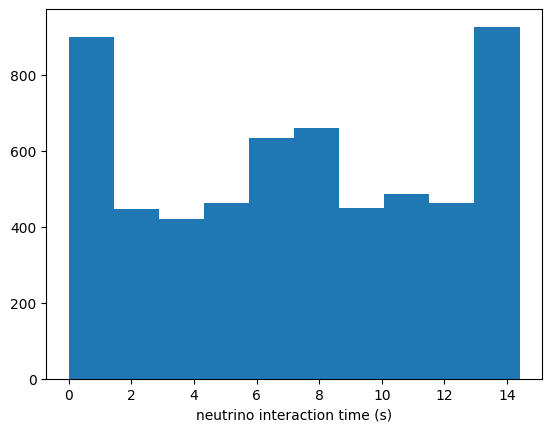

In [8]:
#debugging time plot.
plt.hist(interaction_times)
plt.xlabel("neutrino interaction time (s)")

In [7]:
#Spill level time..
time_sorted_merged_hits = SortByTime(merged_hits_array)

nns_in_hits = np.unique(time_sorted_merged_hits[:,0])
relevant_spill_lookup = {}
for nn_in_hits in nns_in_hits:
    spill = int(full_spill_lookup[int(nn_in_hits)][1])
    relevant_spill_lookup[nn_in_hits] = spill  

#Just go ahead and add the information to the time_sorted_merged_hits for convenience. 
spill_nos = []
for hit in time_sorted_merged_hits:
    nn = hit[0]
    spill_nos.append(relevant_spill_lookup[nn])

time_sorted_merged_hits_spillnos = np.column_stack((time_sorted_merged_hits,spill_nos)) #use this object moving forward!

NameError: name 'full_spill_lookup' is not defined

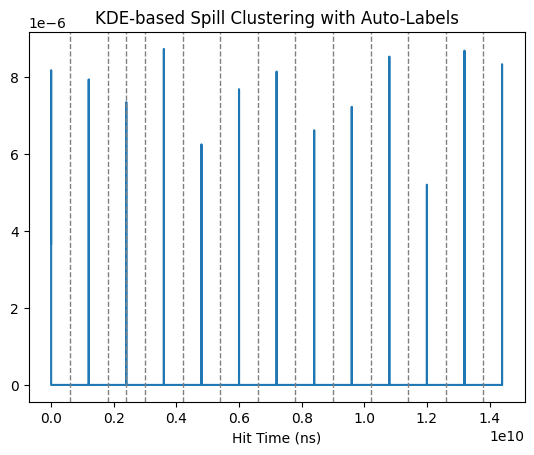

We found 14 clusters


In [10]:
#Quite impressive, lets just let it play with the full information! Haha with settings like bandwidth = 100 and mesh_points = 1000000 we found a good mapping to the truth spill structure!
file_clustered = MakeKDSegmentsSpill(time_sorted_merged_hits_spillnos, bandwidth = 1000, mesh_points = 2500000, plot = True)
#just to be clear the output of this look like:
#(collective_neutrino_number, collective_hit_number, bar_x, bar_y, bar_z, collective_time, total_pe, bar_orientation_code, file_no, truth_spill, clustered_spill)

In [11]:
spill_clustered_right = len(file_clustered[file_clustered[:,-1] == file_clustered[:,-2]])
spills_correct = spill_clustered_right / len(file_clustered)
print(spills_correct)
#Will want to be looking our for stuff that get's split across spills but I would be fairly surprised if that ends up happening at all. 

0.2391611031632491


In [12]:
#Now for let's cluster each spill! 
post_2nd_cluster = []
spills = np.unique(file_clustered[:,-2])
#I think best approach here will be clustering each one on their own, merging, and then evaluating bulk performance? Will just need to be careful about indexing, obv will need to the clustered spill number and cluster number within spill
for spill_no in spills:
    selected_spill = spill_no
    hits_in_spill = file_clustered[file_clustered[:,-2] == selected_spill ] #grabbing our desired spill.  
    time_segmented = MakeKDSegmentsSpill(hits_in_spill, bandwidth = 20, mesh_points = 5000, plot = False)
    post_2nd_cluster.append(time_segmented)

#(collective_neutrino_number, collective_hit_number, bar_x, bar_y, bar_z, collective_time, total_pe, bar_orientation_code, file_no, truth_spill, clustered_spill, clustered_segment)

We found 114 clusters
We found 109 clusters
We found 121 clusters
We found 113 clusters
We found 101 clusters
We found 110 clusters
We found 114 clusters
We found 112 clusters
We found 111 clusters
We found 105 clusters
We found 106 clusters
We found 123 clusters
We found 108 clusters


In [13]:
neutrino_truth_array = ReturnNeutrinoInfoArray(SortByTime(merged_hits_array), n_neutrino_events)
unmasked_cluster_eval, masked_cluster_eval, cluster_occupancy = FullFileClusterEvaluate(post_2nd_cluster, neutrino_truth_array, n_neutrino_events)

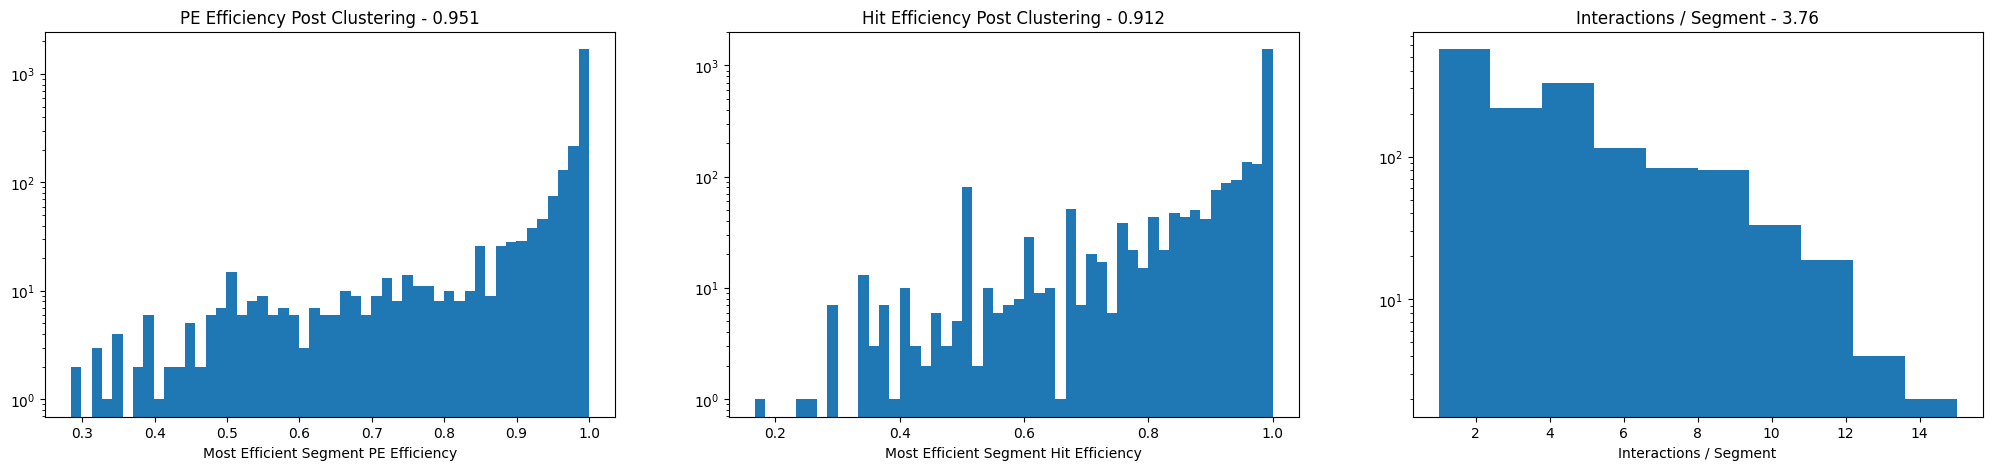

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5)) 

# Plot 1: PE Efficiency Post Clustering
mean_PE_eff = np.mean(masked_cluster_eval[:,2])
axes[0].hist(masked_cluster_eval[:,2], bins=50)
axes[0].set_title(f"PE Efficiency Post Clustering - {mean_PE_eff:.3f}")
axes[0].set_xlabel("Most Efficient Segment PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency Post Clustering 
mean_hit_eff =np.mean(masked_cluster_eval[:,1])
axes[1].hist(masked_cluster_eval[:,1], bins=50)
axes[1].set_title(f"Hit Efficiency Post Clustering - {mean_hit_eff:.3f}")
axes[1].set_xlabel("Most Efficient Segment Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Cluster occupancy (interactions / cluster)
avg_cluster_purity = np.mean(cluster_occupancy)
axes[2].hist(cluster_occupancy)
axes[2].set_title(f"Interactions / Segment - {avg_cluster_purity:.2f}")
axes[2].set_xlabel("Interactions / Segment")
axes[2].set_yscale('log')

In [15]:
#Let's take a look at some of these higher occupancy segments. 
total_occupancy = [] # a list of lists, one list per spill, each list is filled with arrays denoting the segment number and its occupancy 
for i, spill_wise in enumerate(post_2nd_cluster):
    segment_nos = np.unique(spill_wise[:,-1])
    spill_occupancy = []
    for segment in segment_nos:
        sub_array = spill_wise[spill_wise[:,-1] == segment ] #sub array containing hits in the segment 
        interactions = len(np.unique(sub_array[:,0]))
        spill_occupancy.append(np.array((segment, interactions)))
        
    spill_occupancy_array = np.vstack(spill_occupancy)   
    total_occupancy.append(spill_occupancy_array)   

#print(total_occupancy[1])
spill_choice = 0
max_index = np.argmax(total_occupancy[spill_choice][:,1])
print(max_index)
print(total_occupancy[spill_choice][max_index])

13
[13. 11.]


Text(0.5, 1.0, 'Time Segment 25, Spill 0')

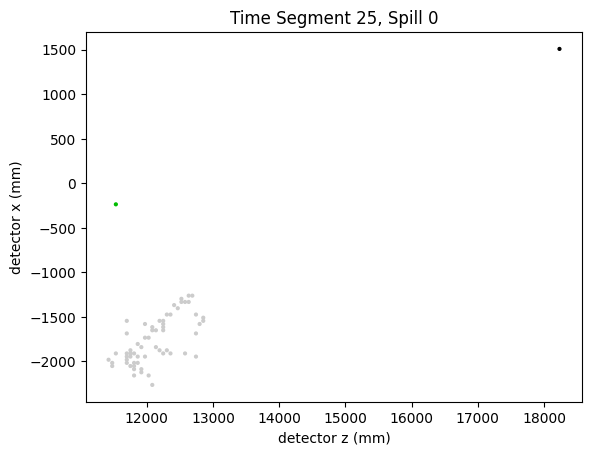

In [16]:
#This cell will plot an event display for a segment given a spill and cluster number:
seg_spill_number = 0
seg_number = 25
seg_sub_array = post_2nd_cluster[seg_spill_number][post_2nd_cluster[seg_spill_number][:,-1] == seg_number ]

nns = seg_sub_array[:,0]
xs = seg_sub_array[:,2] 
zs = seg_sub_array[:,4]

unique_vals, inverse = np.unique(nns, return_inverse=True)

# Map to 1-based index (for neutrino number coloring)
mapped = inverse + 1
nns_mapped = mapped

plt.scatter(zs, xs, s = 4, c = nns_mapped, cmap = 'nipy_spectral')
plt.xlabel("detector z (mm)")
plt.ylabel("detector x (mm)")
plt.title(f"Time Segment {seg_number}, Spill {seg_spill_number}") 

In [12]:
#Lets go ahead and test to see whether the python routine worked
time_segmented = np.load('/sdf/home/k/ktwall/DUNE-TMS_timing_study/python/hits_time_segmented_band_fine_10_fine_mesh_10000_2521.npz')
hits_segmented = time_segmented['first']
occ = time_segmented['third']

In [18]:
#Grab all the hits in the 0th spill
zero_spill_sub_array = hits_segmented[hits_segmented[:,-2] == 0]

Text(0.5, 1.0, 'Time Segment 25, Spill 0')

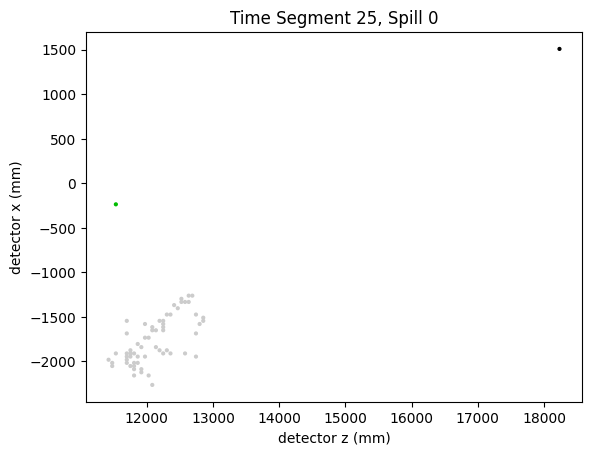

In [19]:
test_sub_array = zero_spill_sub_array[zero_spill_sub_array[:,-1] == seg_number]

nns = test_sub_array[:,0]
xs = test_sub_array[:,2] 
zs = test_sub_array[:,4]

unique_vals, inverse = np.unique(nns, return_inverse=True)

# Map to 1-based index (for neutrino number coloring)
mapped = inverse + 1
nns_mapped = mapped

plt.scatter(zs, xs, s = 4, c = nns_mapped, cmap = 'nipy_spectral')
plt.xlabel("detector z (mm)")
plt.ylabel("detector x (mm)")
plt.title(f"Time Segment {seg_number}, Spill {seg_spill_number}") 

In [26]:
#We did a run on a larger chunk of files lets see how it went. 

time_clustered_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills' #put your time sliced directory here
time_clustered_paths = glob.glob(os.path.join(time_clustered_directory, "*.npz")) #glob can grab all files that fit the *.root condition, forms list of them!

In [27]:
big_pe_eff = []
big_hit_eff = []
big_occupancy = [] 
spill_accuracy = []
for file_path in time_clustered_paths:
    with np.load(file_path) as file:
        #quickly check the spill stuff
        print(file_path)
        seg_hits = file['first']
        spill_nos = np.unique(seg_hits[:,-2])
        clustered_spills = len(np.unique(seg_hits[:,-2]))
        true_spills = len(np.unique(seg_hits[:,-3]))
        if 1 == 1: #len(spill_nos) > 8:
            big_pe_eff.append(file['second'][:,2])
            big_hit_eff.append(file['second'][:,1])
            big_occupancy.append(file['third'])

        print(f"Clustered spills - {clustered_spills}, True spills - {true_spills}")
        spill_accuracy.append(clustered_spills/true_spills)
big_pe_array = np.hstack(big_pe_eff)
big_hit_array = np.hstack(big_hit_eff)
big_occupancy_array = np.hstack(big_occupancy)

/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2526.npz
Clustered spills - 17, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2509.npz
Clustered spills - 14, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2508.npz
Clustered spills - 18, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2552.npz
Clustered spills - 15, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2502.npz
Clustered spills - 15, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/hits_time_segmented_band_fine_20_2533.npz
Clustered spills - 18, True spills - 13
/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/tru

150458


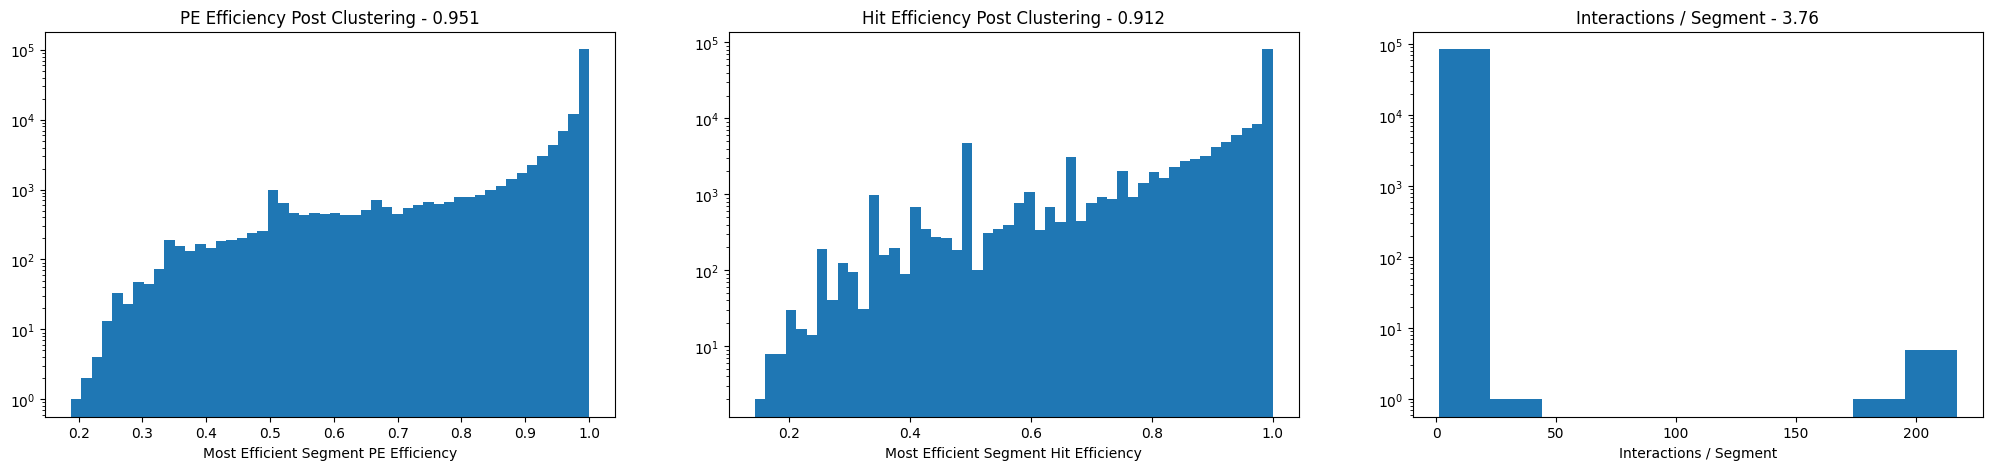

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5)) 

# Plot 1: PE Efficiency Post Clustering
print(len(big_pe_array))
mean_PE_eff = np.mean(big_pe_array)
axes[0].hist(big_pe_array, bins=50)
axes[0].set_title(f"PE Efficiency Post Clustering - {mean_PE_eff:.3f}")
axes[0].set_xlabel("Most Efficient Segment PE Efficiency")
axes[0].set_yscale('log')

# Plot 2: Hit Efficiency Post Clustering 
mean_hit_eff =np.mean(big_hit_array)
axes[1].hist(big_hit_array, bins=50)
axes[1].set_title(f"Hit Efficiency Post Clustering - {mean_hit_eff:.3f}")
axes[1].set_xlabel("Most Efficient Segment Hit Efficiency")
axes[1].set_yscale('log')

# Plot 3: Cluster occupancy (interactions / cluster)
avg_cluster_purity = np.mean(big_occupancy_array)
axes[2].hist(big_occupancy_array)
axes[2].set_title(f"Interactions / Segment - {avg_cluster_purity:.2f}")
axes[2].set_xlabel("Interactions / Segment")
#axes[2].set_xlim((0,100))
axes[2].set_yscale('log')

Text(0.5, 1.0, "Fraction of KDE found spills vs 'true' spills")

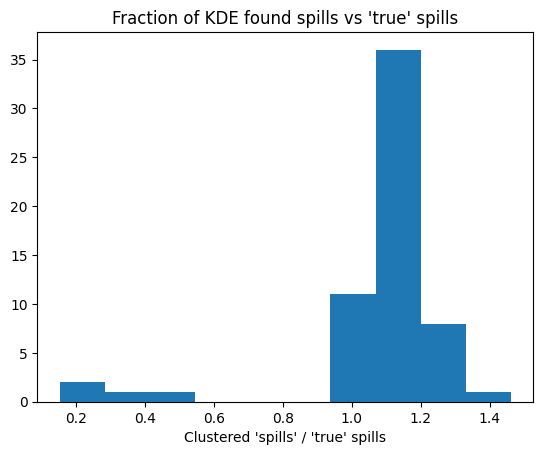

In [23]:
plt.hist(spill_accuracy)
plt.xlabel("Clustered 'spills' / 'true' spills")
plt.title("Fraction of KDE found spills vs 'true' spills")